<a href="https://colab.research.google.com/github/aarti-raut/AML-Lab-Experiments/blob/main/Experiment_06_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 6: Support Vector Machine (SVM)
**Dataset:** Iris Dataset (UCI ML Repository)
**Aim:** Train the system using Iris dataset and determine accuracy using SVM.

In [1]:
from sklearn.datasets import load_iris
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Load dataset
iris = load_iris()
X, y = iris.data, iris.target
print('Dataset: Iris')
print(f'Samples: {X.shape[0]}, Features: {X.shape[1]}')


Dataset: Iris
Samples: 150, Features: 4


In [2]:
# Preprocess and split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# Train SVM with RBF kernel
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)
print('SVM model trained with RBF kernel!')
print(f'Number of Support Vectors: {sum(svm_model.n_support_)}')


SVM model trained with RBF kernel!
Number of Support Vectors: 46


In [3]:
# Predict and evaluate
y_pred = svm_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'=== Model Accuracy: {accuracy * 100:.2f}% ===')
print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print('=== Confusion Matrix ===')
print(confusion_matrix(y_test, y_pred))


=== Model Accuracy: 100.00% ===

=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

=== Confusion Matrix ===
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


Kernel: linear   | Accuracy: 96.67%
Kernel: poly     | Accuracy: 96.67%
Kernel: rbf      | Accuracy: 100.00%
Kernel: sigmoid  | Accuracy: 90.00%


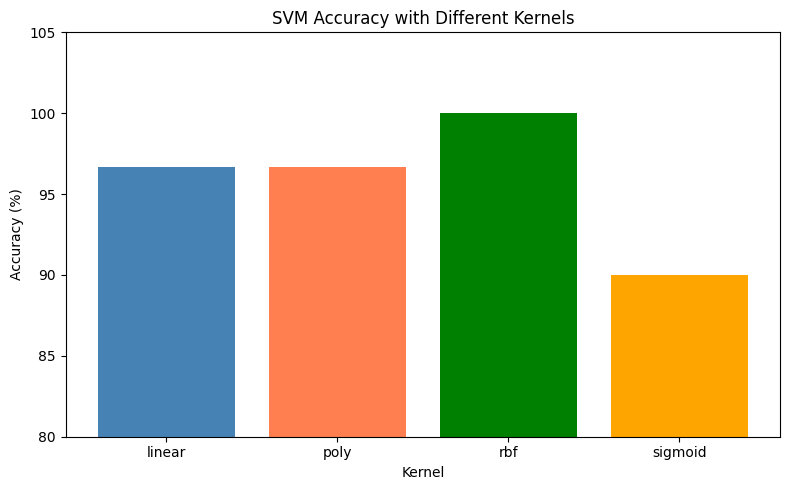

In [4]:
# Compare different SVM kernels
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_accuracies = []

for k in kernels:
    model = SVC(kernel=k, random_state=42)
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    kernel_accuracies.append(acc * 100)
    print(f'Kernel: {k:8s} | Accuracy: {acc*100:.2f}%')

# Plot
plt.figure(figsize=(8, 5))
plt.bar(kernels, kernel_accuracies, color=['steelblue','coral','green','orange'])
plt.title('SVM Accuracy with Different Kernels')
plt.xlabel('Kernel')
plt.ylabel('Accuracy (%)')
plt.ylim([80, 105])
plt.tight_layout()
plt.show()
